## Imports

In [34]:
import pandas as pd
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import spacy
import contractions
import re
import emoji
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, RobustScaler,  MultiLabelBinarizer
from sklearn.metrics import silhouette_score, make_scorer, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold, KFold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.utils import resample
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

nlp = spacy.load("en_core_web_sm")
rs = 42

# 1. Préparation des données

In [35]:
data = pd.read_csv("../scitweets_export.tsv", sep="\t", index_col=0)

## A. Encodage des classes

On définit la class de chaque tweets, cad soit:
- science_related / not science related (mode = 0)
- {claim, ref} / {context} (mode = 1)
- claim / ref / context (mode = 2)

Pour les deux derniers, on conservera uniquement les données science_related.
Par ailleurs pous les deux dernières classification, une donnée peut appartenir à plusieurs classes, on encode donc la cible sous forme d'un vecteur binaire.

In [36]:
classif_mode = 2

In [37]:
if classif_mode == 0:
    data['target'] = data.apply(lambda x: [int(x['science_related'])], axis=1)
    class_map = {
        0: "not science related",
        1: "science related",
    }
elif classif_mode == 1:
    data = data[data['science_related'] == 1]
    data['target'] = data.apply(lambda x: [int(x['scientific_claim']) | int(x['scientific_reference']), int(x['scientific_context'])], axis=1)
    class_map = {
        0: "knowledge",
        1: "context",
    }
elif classif_mode == 2:
    data = data[data['science_related'] == 1]
    data['target'] = data.apply(lambda x: [int(x['scientific_claim']), int(x['scientific_reference']), int(x['scientific_context'])], axis=1)
    class_map = {
        0: "claim",
        1: "reference",
        2: "context"
    }
else:
    raise ValueError(f"classif_mode {classif_mode} is not supported, choose within 0, 1, 2")

data = data.drop(columns=['tweet_id', 'science_related', 'scientific_claim', 'scientific_reference', 'scientific_context'])

## B. Équilibrage des classes

On va supprimer et/ou créer des données pour avoir une quantité similaire de données dans chaque classes

### Visualisation de la répartition des classes

Légende : 
- 0 = données qui n'appartiennent pas à une classe
- 1 = données qui appartiennent à une classe

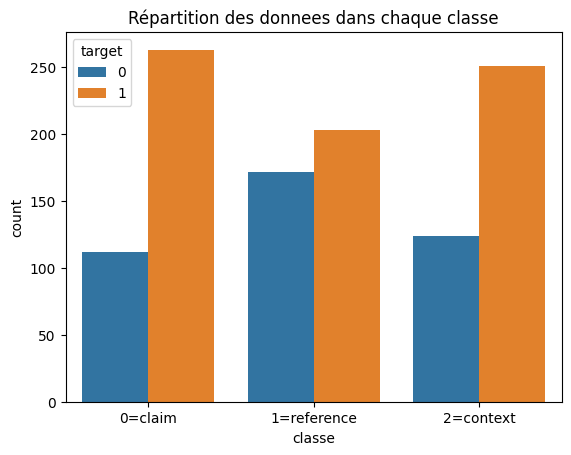

In [38]:
def class_balance_plot(df):
    classes_counts = df.copy()
    classes_counts['t_index'] = classes_counts['target'].apply(lambda x: list(enumerate(x)))
    classes_counts = classes_counts.explode(['target', 't_index'], ignore_index=True)
    classes_counts['classe'] = classes_counts['t_index'].apply(lambda x: f"{x[0]}={class_map[x[0]]}")

    sns.countplot(data=classes_counts, x="classe", hue="target")
    plt.title("Répartition des donnees dans chaque classe")
    plt.show()
    
class_balance_plot(data)

### Over / Undersampling

Duplication ou suppression de certain tweets afin d'équilibrer les données dans chaque classes

In [39]:
def over_under_sample(class_id, class_value, n, df):
    # set the number of data with class <class_id> set to <class_value> to <n> data
    # perform undersampling if the current number of data with <class_id> is superior to <n>, perform undersampling otherwise
    sample_from = df[df['target'].apply(lambda x: x[class_id] == class_value)]
    not_sample_from = df[df['target'].apply(lambda x: x[class_id] != class_value)]

    if len(sample_from) < n: # Oversampling
        to_sample = n - len(sample_from)
        new_data = resample(
            sample_from, 
            replace=len(sample_from) < to_sample,
            n_samples=to_sample,  
            random_state=rs
        )
        resample_from = pd.concat([sample_from, new_data])
    
    elif len(sample_from) > n: # Undersampling
        to_sample = n
        new_data = resample(
            sample_from, 
            replace=False,
            n_samples=to_sample,  
            random_state=rs
        )
        resample_from = new_data
    
    else:
        resample_from = sample_from
    
    new_df = pd.concat([resample_from, not_sample_from])    
    new_df = new_df.sample(frac=1, random_state=rs).reset_index(drop=True)
    return new_df


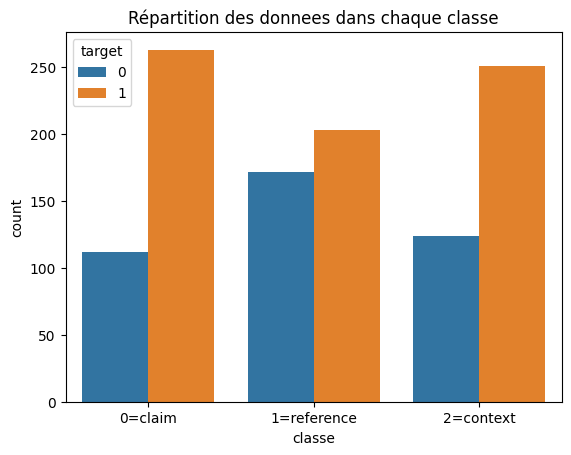

In [40]:
# Use over_under_sample to balance classes here
resampled = data.copy()

# example
#resampled = over_under_sample(1, 1, 150, resampled)

class_balance_plot(resampled)

### Appliquer les modification

Dans le cas ou des équilibrages doivent être conservés, on applique les modifications sur data

In [41]:
data = resampled

## C. Jeu de test final

On met de côté une proportion des données qui ne sera jamais utilisé durant les entrainements

In [42]:
test_size = 0.1

In [43]:
X = data.drop(columns=['target'])
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=rs, stratify=y
)

datatest = pd.DataFrame(X_test, columns=X.columns)
datatest['target'] = y_test

data = pd.DataFrame(X_train, columns=X.columns)
data['target'] = y_train

## D. Sauvegarde du jeu de données

In [44]:
data.to_csv("data.csv", index=False)
datatest.to_csv("test.csv", index=False)

# 2. Prétraitement du texte

In [45]:
data = pd.read_csv("data.csv")
data['target'] = data['target'].apply(ast.literal_eval)

## A. Suppression des contractions

Par exemple I'm devient I am

In [46]:
data["text"] = data.apply(lambda x: contractions.fix(x["text"]), axis=1)

## B. Encodage des entitées

Les entitées sont encodées par des identifiants directement dans les tweets pour faciliter la tokenization:
- @someone : mention someone
- #something : hashtag something
- http:/t.co/eehfd : url
- 🏀 : emoticon
- 42 : number
- 50$ : number money
- 30% : number percent
- some_some : some some

In [47]:
def encode_tags(txt, setting):
    if setting == "replace":
        return re.sub(r'#([\w_]+)', r' hashtag \1 ', txt)
    elif setting == "delete":
        return re.sub(r'#([\w_]+)', r' ', txt)
    return txt

def encode_mention(txt, setting):
    if setting == "replace":
        return re.sub(r'@([\w_]+)', r' mention \1 ', txt)
    elif setting == "delete":
        return re.sub(r'@([\w_]+)', r' ', txt)
    return txt

def encode_url(txt, setting):
    expr = r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+'
    if setting == "encode":
        return re.sub(expr, " url ", txt)
    elif setting == "delete":
        return re.sub(expr, " ", txt)
    return txt

def encode_underscore(txt, setting):
    if setting == "encode" or setting == "delete":
        return txt.replace("_", " ")
    return txt

def encode_emoji(txt, setting):
    if setting == "replace":
        replacement = " emoticon "
    elif setting == "remove":
        replacement = " "
    else:
        return txt
    
    new_txt = txt
    for token in reversed(nlp(txt)):
        if emoji.is_emoji(token.text):
            new_txt = new_txt[:token.idx] + replacement + new_txt[token.idx + len(token.text):]
            
    return new_txt

def encode_numbers(txt, setting):
    if setting == "none":
        return txt
    
    doc = nlp(txt)
    new_txt = txt
    for ent in reversed(doc.ents):  # reverse so replacements don't mess up indices
        if not "#" in ent.text and ent.label_ in ["CARDINAL", "ORDINAL", "PERCENT", "MONEY"] :
            if setting == "replace":
                replacement = " number " + ent.label_.lower() + " "
            else:
                replacement = " "
            new_txt = new_txt[:ent.start_char] + replacement + new_txt[ent.end_char:]

    return new_txt

def encode(txt, s):
    new_txt = encode_tags(txt, s["tags"])
    new_txt = encode_mention(new_txt, s["mention"])
    new_txt = encode_url(new_txt, s["url"])
    new_txt = encode_emoji(new_txt, s["emoji"])
    new_txt = encode_numbers(new_txt, s["numbers"])
    new_txt = encode_underscore(new_txt, s["underscore"])
    return new_txt

In [48]:
# Choose here what to do with entity ("none", "replace" or "delete") and run to apply
settings = {
    "tags": "replace",
    "mention": "replace",
    "url": "replace",
    "emoji": "replace",
    "numbers": "replace",
    "underscore": "remove"
}

data["text"] = data.apply(lambda x: encode(x["text"], settings), axis=1)


## C. Suppression des stop / close words et de la ponctuation

Les close words sont des mots qui ne tiennent pas beaucoup de sens dans une phrase : conjonction, déterminant, pronom...

On peut conserver les auxiliaires car certain pourrait avoir du sens dans un contexte scientific : "coffe MAY be good for health"

In [49]:
def filter_words(txt, f):
    new_txt = []
    for t in nlp(txt):
        if t.is_alpha and t.pos_ in f:
            new_txt.append(t.text)
    return " ".join(new_txt)

In [50]:
to_keep = [
    "ADJ",   # adjective
    "ADV",   # adverb
    "AUX",   # auxiliary
    "INTJ",  # interjection
    "NOUN",  # noun
    "PROPN", # proper noun
    "VERB",  # verb
]

data["text"] = data.apply(lambda x: filter_words(x["text"], to_keep), axis=1)

## D. Lemmatization et mise en minuscule

Chaque mot est réduit à sa racine pour regrouper les mots au sens similaire

In [51]:
data["text"] = data.apply(lambda x: " ".join([token.lemma_.lower() for token in nlp(x["text"])]), axis=1)

## E. Sauvegarde des données pré-traités

In [52]:
data["text"] = data.apply(lambda x: x["text"].rstrip(), axis=1)
data = data[data['text'] != ""] # Au cas ou certain tweets n'aurait plus aucun mots
data.to_csv("preprocessed.csv", index=False)

# 3. Vectorisation

Le texte est transformé en vecteur de nombres pour être traité par le model. Pour chaque vectorization on évalue un indice de séparation des classes appelé silouhette score : plus il est proche de 1 mieux les données sont séparés. On visualise aussi les données en 3d et 2d grace a une réduction de dimension (PCA).

In [53]:
data = pd.read_csv("preprocessed.csv")
data['target'] = data['target'].apply(ast.literal_eval)

In [54]:
def vectorize_df(df, vectorizer):
    vectorizer.fit(df["text"])
    vectorized = pd.DataFrame(
        data=vectorizer.transform(df['text']).toarray(),
        columns=vectorizer.get_feature_names_out()
    )
    vectorized["target"] = df["target"].reset_index(drop=True)
    return vectorized

def normalize_df(df, scaler):
    scaled_array = scaler.fit_transform(df.drop(columns=["target"]))
    scaled = pd.DataFrame(scaled_array, columns=df.drop(columns=["target"]).columns)
    scaled["target"] = df["target"].reset_index(drop=True)
    return scaled

def display_separation(data):
    pca = PCA(n_components=3)
    reduced_data = pca.fit_transform(data.drop("target", axis=1))

    reduced_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
    le = LabelEncoder()
    reduced_df['target'] = le.fit_transform(data['target'].astype(str))
    print(f"Figure labels : {le.classes_}")

    fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(14, 6))
    ax1.axis('off')
    ax1 = fig.add_subplot(121, projection='3d')

    ax1.scatter(reduced_df['PC1'], reduced_df['PC2'], reduced_df['PC3'], c=reduced_df['target'], marker='o')
    ax1.set_xlabel('PC 1')
    ax1.set_ylabel('PC 2')
    ax1.set_zlabel('PC 3')

    sns.scatterplot(x=reduced_df['PC1'], y=reduced_df['PC2'], hue=reduced_df['target'], ax=ax2)
    ax2.set_xlabel('PC 1')
    ax2.set_ylabel('PC 2')

    plt.subplots_adjust(wspace=0.3)
    plt.title("Data Separation with PCA reduction (3d / 2d)")
    plt.show()

def get_silouhette(df):
    X = df.drop(columns=["target"])
    y = np.array(df["target"].to_list())

    # Calculate silhouette score for each label (per label)
    sil_scores_multi = []
    for label_idx in range(y.shape[1]):
        sil_score = silhouette_score(X, y[:, label_idx])
        sil_scores_multi.append(sil_score)

    # Average silhouette score for multi-labeled data
    avg_sil_score = sum(sil_scores_multi) / len(sil_scores_multi)
    return avg_sil_score

## A. Vectorization Count

Average Silhouette Score for Count Vectorizer: -0.005778967647324971
Figure labels : ['[0, 0, 1]' '[0, 1, 1]' '[1, 0, 0]' '[1, 0, 1]' '[1, 1, 1]']


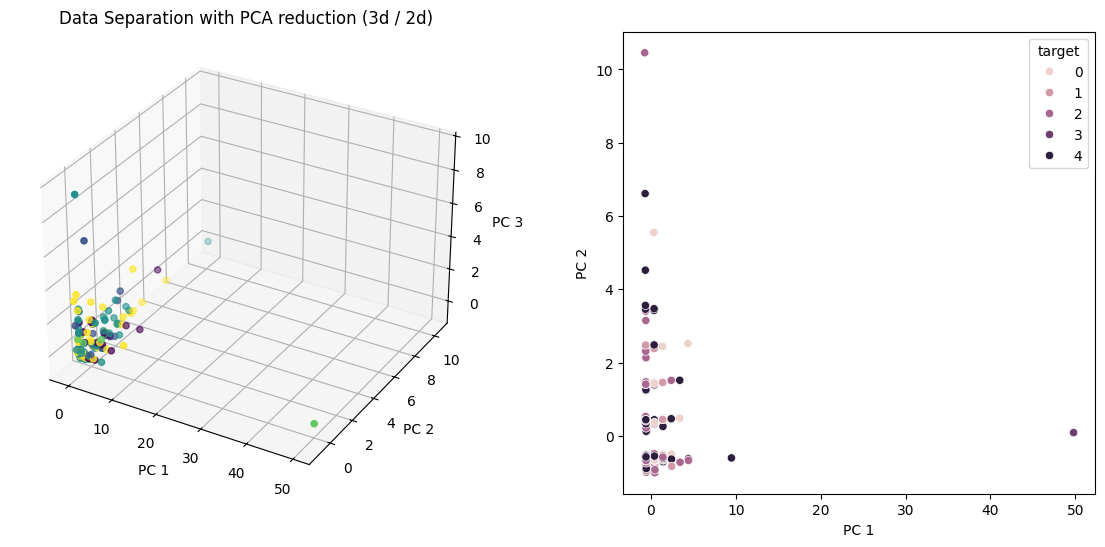

In [55]:
cv = CountVectorizer(
    ngram_range=(1,1),
    min_df=1,
    max_df=1.0,
    strip_accents='ascii'
)
cv_data = vectorize_df(data, cv)
print(f"Average Silhouette Score for Count Vectorizer: {get_silouhette(cv_data)}")
display_separation(cv_data)

## B. Vectorization TF-IDF

Average Silhouette Score for TF-IDF: 0.0010733129674769342
Figure labels : ['[0, 0, 1]' '[0, 1, 1]' '[1, 0, 0]' '[1, 0, 1]' '[1, 1, 1]']


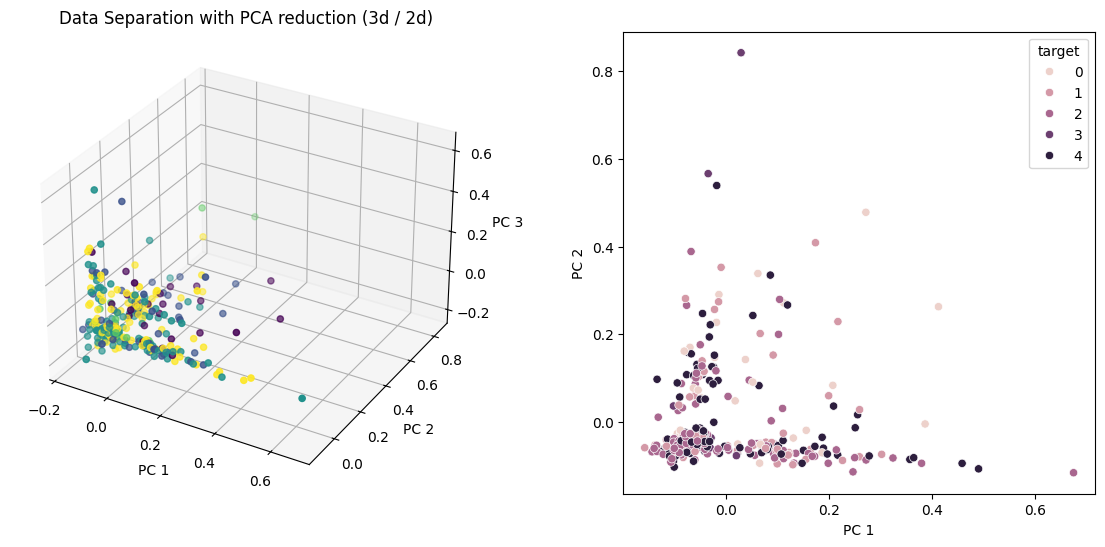

In [56]:
tf = TfidfVectorizer(
    ngram_range=(1,1),
    min_df=1,
    max_df=1.0,
    strip_accents='ascii'
)
tf_data = vectorize_df(data, tf)
print(f"Average Silhouette Score for TF-IDF: {get_silouhette(tf_data)}")
display_separation(tf_data)

## C. Normalisation

On peut normaliser les données pour que toutes les features aient un poid équivalent. Cela peut être effectué avec différentes méthodes par exemple MinMaxScaler, StandardScaler ou RobustScaler. 

Ici on teste toutes les combinaisons de vectorisation + normalisation pour trouver celle qui à le meilleur silouhette score.

In [57]:
scalers = {
    "min_max": MinMaxScaler(),
    "std": StandardScaler(),
    "robust": RobustScaler(),
}
to_scale = {
    "tfidf": tf_data,
    "cv": cv_data,
}

results = []
results.append(("tfidf", "none", get_silouhette(tf_data)))
results.append(("cv", "none", get_silouhette(cv_data)))
for s, d in product(scalers.keys(), to_scale.keys()):
    scaled = normalize_df(to_scale[d], scalers[s])
    results.append((d, s, get_silouhette(scaled)))

results = sorted(results, key=lambda x: x[2], reverse=True)
results_df = pd.DataFrame(results, columns=['Vectorization', 'Scaling', 'Silouhette'])
results_df

,Vectorization,Scaling,Silouhette
0,tfidf,robust,0.002668
1,tfidf,none,0.001073
2,cv,min_max,-0.001795
3,tfidf,std,-0.002382
4,tfidf,min_max,-0.002443
5,cv,std,-0.002458
6,cv,none,-0.005779
7,cv,robust,-0.005779


## D. Sauvegarde des données vectorisés

D'après le tableau précédent on choisit une vectorisation et une normalisation pertinente pour enregistrer les données vectorisés

In [58]:
data = normalize_df(to_scale["tfidf"], scalers["robust"])
data.to_csv("vectorized.csv")

# 4. Choix du modèle

On doit tester un panel de modèl pour voir lesquels sont les plus pertinents. On test plusieurs modèles et on évalue leur accuracy sur une cross validation : pour évaluer de la robustesse d'un modèle on se base surtout sur l'accuracy la plus faible.

In [59]:
data = pd.read_csv("vectorized.csv")
data['target'] = data['target'].apply(ast.literal_eval)

In [66]:
# Compute an average accuracy accross labels
def multilabel_accuracy(y_true, y_pred):
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) 
                    for i in range(y_true.shape[1])])

# Compute an average f1-score accross labels
def multilabel_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='samples')

# Perform cross validation for 1 model return f1-score and accuracy for each fold
def cross_validate_model(dataframe, model, n_splits=5, random_state=None):
    X = dataframe.drop(columns=["target"]).values
    y = np.array(list(dataframe["target"].values))

    is_multilabel = y.shape[1] > 1

    # Define custom scorers
    if is_multilabel:
        scoring = {
            'accuracy': make_scorer(multilabel_accuracy),
            'f1': make_scorer(multilabel_f1)
        }
        model = MultiOutputClassifier(model)
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    else:
        y = dataframe["target"].apply(lambda x: x[0]).values
        scoring = ['accuracy', 'f1']
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Run cross-validation
    results = cross_validate(
        model, X, y, 
        scoring=scoring, 
        cv=cv, 
        return_train_score=False,
        n_jobs=-1
    )

    return {
        'accuracy': results['test_accuracy'],
        'f1': results['test_f1']
    }

# Evaluate multiple model on the same datas
def evaluate_by_models(dataframe, models, n_splits=5, random_state=None):
    results = {}

    for name, model in models.items():
        print(f"Evaluating model: {name}")
        metrics = cross_validate_model(
            dataframe=dataframe,
            model=model,
            n_splits=n_splits,
            random_state=random_state
        )
        results[name] = metrics

    return results

# Evaluate one model on multiple data
def evaluate_by_df(dataframes, model, n_splits=5, random_state=None):
    results = {}

    for name, df in dataframes.items():
        print(f"Evaluating data: {name}")
        metrics = cross_validate_model(
            dataframe=df,
            model=model,
            n_splits=n_splits,
            random_state=random_state
        )
        results[name] = metrics

    return results

# Draw a boxplot for each metrics
def plot_model_comparison(results_dict, metric):
    if metric not in ['accuracy', 'f1']:
        raise ValueError("Metric must be either 'accuracy' or 'f1'.")

    # Flatten the results into a DataFrame for seaborn
    records = []
    for name, metrics in results_dict.items():
        if metric not in metrics:
            raise ValueError(f"Metric '{metric}' not found in results for model: {name}")
        for score in metrics[metric]:
            records.append({'Model': name, metric.capitalize(): score})

    df_plot = pd.DataFrame(records)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot, x='Model', y=metric.capitalize(), hue='Model', palette="Set2", dodge=False)
    plt.title(f'Model Comparison by {metric.capitalize()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Evaluating model: SVM
Evaluating model: Naive Bayes
Evaluating model: K-NN
Evaluating model: DT
Evaluating model: Random Forest


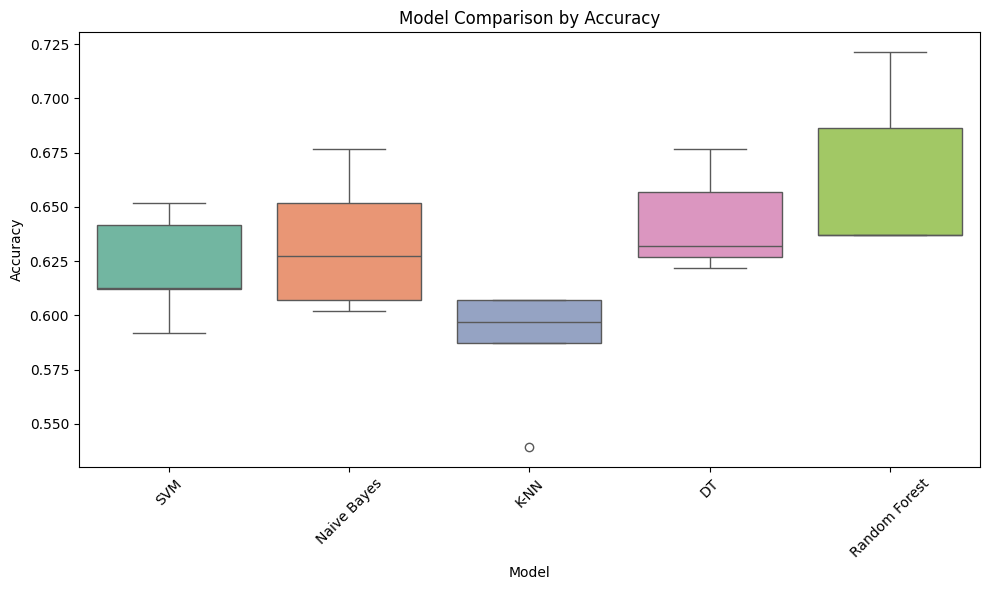

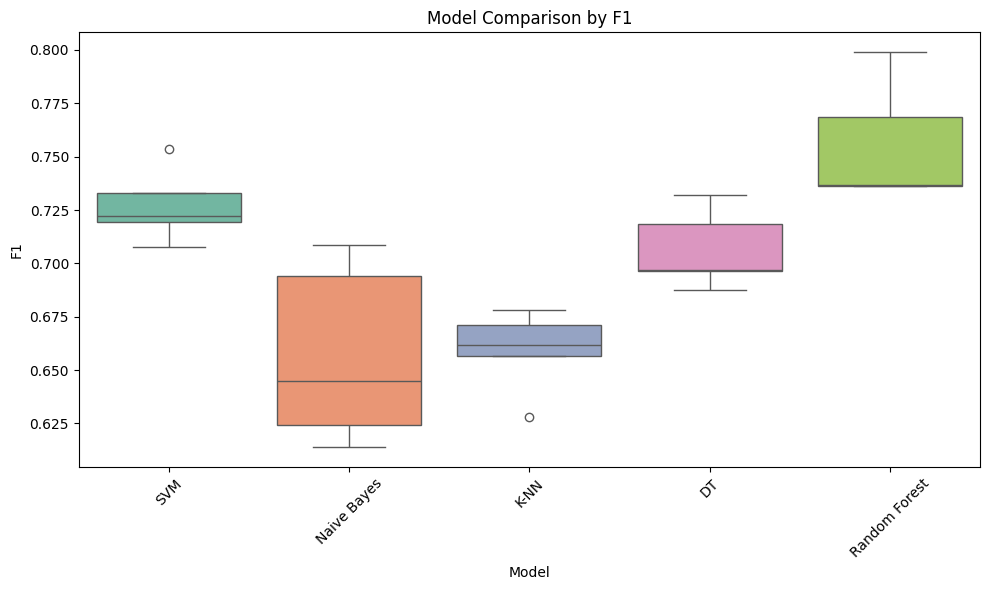

In [68]:
panel = {
    'SVM': SVC(random_state=rs),
    'Naive Bayes': GaussianNB(),
    'K-NN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(random_state=rs),
    'Random Forest': RandomForestClassifier(random_state=rs)
}

results = evaluate_by_models(data, panel, 5, rs)
plot_model_comparison(results, "accuracy")
plot_model_comparison(results, "f1")